# Editing Fraser River Hydrograph

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
fraser['date'] = pd.to_datetime(fraser[['year','month','day']])
# fraser = fraser.drop(columns=['year','month','day'])
fraser

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4166229/164222624.py:1: SyntaxWarning: invalid escape sequence '\s'
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
/tmp/ipykernel_4166229/164222624.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/SOG-forcing/ECget/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
/tmp/ipykernel_4166229/164222624.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  fraser = pd.read_csv('/data/dlatorne/SOG-projects/S

,year,month,day,flow,date
0,1912,3.0,1.0,538.000,1912-03-01
1,1912,3.0,2.0,538.000,1912-03-02
2,1912,3.0,3.0,538.000,1912-03-03
3,1912,3.0,4.0,538.000,1912-03-04
4,1912,3.0,5.0,538.000,1912-03-05
...,...,...,...,...,...
41702,2026,5.0,7.0,4966.736,2026-05-07
41703,2026,5.0,8.0,5298.021,2026-05-08
41704,2026,5.0,9.0,5470.868,2026-05-09
41705,2026,5.0,10.0,5616.736,2026-05-10


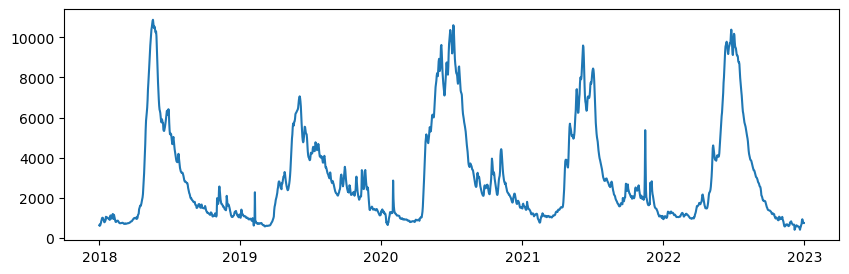

In [3]:
fig, ax = plt.subplots(1,1,figsize=[10,3])

ax.plot(fraser.date[(fraser.year>=2018)&(fraser.year<=2022)],fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)])

In [4]:
Mpeakchange = 8443-7241 # want peak flow to be about 1000 less than before - Morrison2002 table 2
Mminchange = 974-768 # want minimum flow to be about 200 more than before
print(Mpeakchange)
print(Mminchange)

1202
206


In [5]:
np.min(fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)]) # note that this is much lower than the present day minimum flow in Morrison2002 (768, Table 2)

410.8264

In [6]:
np.max(fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)]) # note that this is much higher than the present day peak flow in Morrison2002 (768, Table 2)

10876.47

In [7]:
# since it seems that we were measuring at different points, take percentage change from Morrison 2002 to get the changes to apply here
peakchange = (Mpeakchange/8443)*np.max(fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)])
minchange = (Mminchange/768)*np.min(fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)])

print(peakchange)
print(minchange)

1548.444503138695
110.19562291666666


## 2018

In [8]:
runoff = fraser.flow[fraser.year==2018]

total = np.sum(runoff) # don't want annual total to significantly change
print(total)

990754.9297


In [9]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.8475019812443411


In [10]:
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

new total = 879888.17, or a -11.19% change


In [11]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 400
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")

factor = 0.8107253432358696
new total = 989451.53, or a -0.13% change


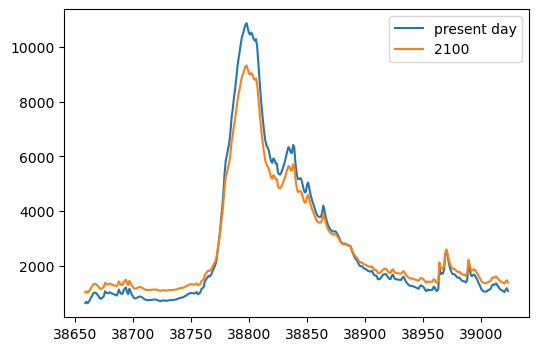

In [12]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

## 2019

In [13]:
runoff = fraser.flow[fraser.year==2019]

total = np.sum(runoff) # don't want annual total to significantly change
print(total)

968150.7172000001


In [14]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.7651012710997486
new total = 780954.75, or a -19.34% change


In [15]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 820
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")

factor = 0.6489718258557733
new total = 967823.94, or a -0.03% change


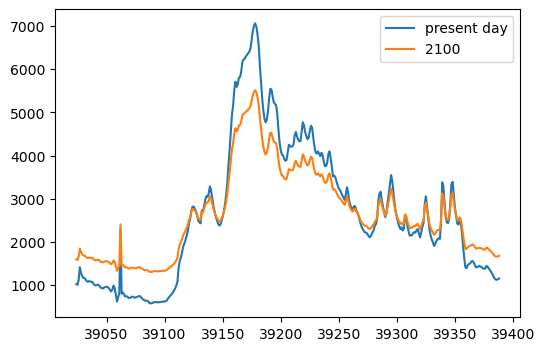

In [16]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

## 2020

In [17]:
runoff = fraser.flow[fraser.year==2020]

total = np.sum(runoff) # don't want annual total to significantly change
print(total)

1324939.3148


In [18]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.8436021251666286
new total = 1158053.22, or a -12.6% change


In [19]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 690
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
#another relly big increasemin to get here

factor = 0.778540071053858
new total = 1324389.95, or a -0.04% change


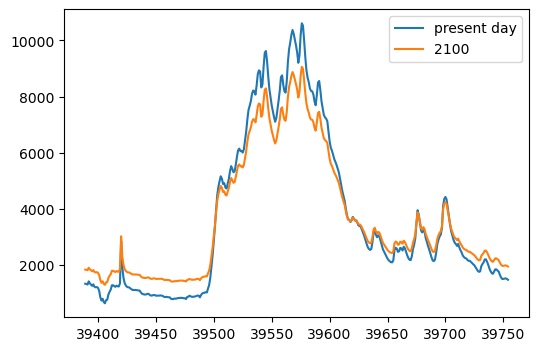

In [20]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

## 2021

In [21]:
runoff = fraser.flow[fraser.year==2021]

total = np.sum(runoff) # don't want annual total to significantly change
print(total)

1072610.5307999998


In [22]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.8271074199147752
new total = 927385.53, or a -13.54% change


In [23]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 570
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
#another relly big increasemin to get here

factor = 0.7676920174410932
new total = 1071705.94, or a -0.08% change


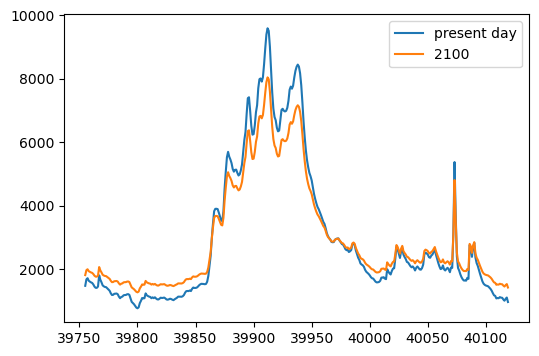

In [24]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

## 2022

In [25]:
runoff = fraser.flow[fraser.year==2022]

total = np.sum(runoff) # don't want annual total to significantly change
print(total)

1065440.202


In [26]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.8402700949385392
new total = 935478.94, or a -12.2% change


factor = 0.7926007411327431
new total = 1065365.1, or a -0.01% change


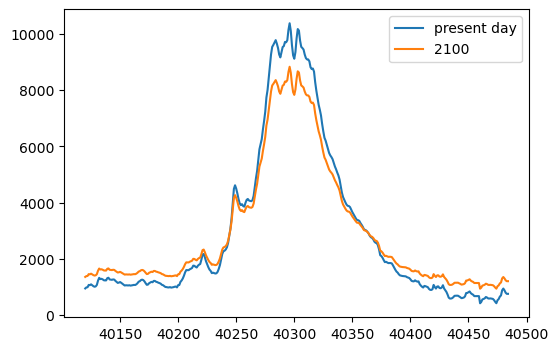

In [27]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 495
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")

fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

## whole timeseries

In [28]:
runoff = fraser.flow[(fraser.year>=2018)&(fraser.year<=2022)]

total = np.sum(runoff) # don't want annual total to significantly change
avg = np.mean(runoff)
print(total)
print(avg)

5421895.6945
2969.2747505476455


In [29]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
# note that morrison had 3% increase whereas Riche 2014 showed no significant change over the last century

factor = 0.8475019812443411
new total = 4796284.55, or a -11.54% change


factor = 0.8042894315843871
new total = 5420210.61, or a -0.03% change
new mean = 2968.35, or a -0.03% change


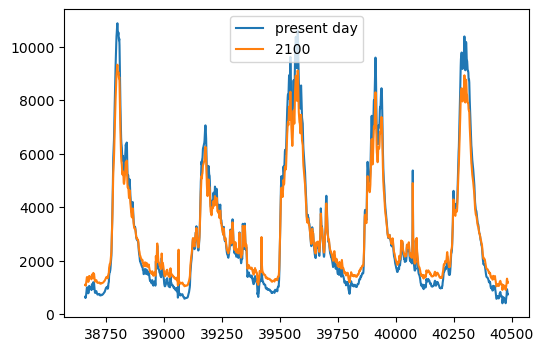

In [30]:
# how much do we need to increase the minimum until we get no significant change
increasemin = 470
factor = (runoff.max() - peakchange - minchange - increasemin)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange + increasemin

# and check
print(f"new total = {np.round(np.sum(newrun),2)}, or a {np.round((np.sum(newrun)/total*100)-100,2)}% change")
print(f"new mean = {np.round(np.mean(newrun),2)}, or a {np.round((np.mean(newrun)/avg*100)-100,2)}% change")

fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff, label='present day')
ax.plot(newrun, label='2100')
ax.legend()

In [31]:
# using the min change from the full timeseries analysis lets calculate what percentage of the present day min that value is
newminchange = minchange+increasemin
print(newminchange/np.min(runoff)+1)

2.4122647008971834


algorhythm becomes flow*0.8+(minflow*2.4) 